Setup and connect

In [2]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

project_id = "olist-analytics-493621"
client = bigquery.Client(project=project_id)
print("Connected!")

Connected!


Pull RFM data from BigQuery

In [3]:
df_rfm = client.query("""
    SELECT
        customer_unique_id,
        customer_state,
        recency,
        frequency,
        monetary,
        r_score,
        f_score,
        m_score,
        rfm_score,
        customer_segment
    FROM `olist_analytics.mart_rfm`
    WHERE monetary > 0
""").to_dataframe()

print(f"Total customers: {len(df_rfm):,}")
print(f"\nColumns: {df_rfm.columns.tolist()}")
print(f"\nSample:")
df_rfm.head()

/Users/maytilok/dbt-env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Total customers: 95,539

Columns: ['customer_unique_id', 'customer_state', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'customer_segment']

Sample:


,customer_unique_id,customer_state,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment
0,317cfc692e3f86c45c95697c61c853a6,SP,53,1,9.59,5,4,1,3.33,Promising
1,bd06ce0e06ad77a7f681f1a4960a3cc6,SP,399,1,10.07,2,3,1,2.00,At Risk
2,b33336f46234b24a613ad9064d13106d,SP,118,1,10.89,5,5,1,3.67,Recent
3,6f5b9d1cdccc4d28f0483a612edecacf,SP,410,1,11.63,2,5,1,2.67,At Risk
4,2878e5b88167faab17d4fb83a986d38b,SP,353,1,11.63,2,4,1,2.33,At Risk


# Segment overview

In [4]:
segment_summary = (
    df_rfm.groupby('customer_segment')
    .agg(
        count        = ('customer_unique_id', 'count'),
        avg_recency  = ('recency', 'mean'),
        avg_frequency= ('frequency', 'mean'),
        avg_monetary = ('monetary', 'mean'),
        total_revenue= ('monetary', 'sum')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

segment_summary['pct_customers'] = (
    segment_summary['count'] / len(df_rfm) * 100
).round(1)

segment_summary['pct_revenue'] = (
    segment_summary['total_revenue'] / df_rfm['monetary'].sum() * 100
).round(1)

print("=" * 70)
print("CUSTOMER SEGMENT SUMMARY")
print("=" * 70)
print(segment_summary.to_string(index=False))

CUSTOMER SEGMENT SUMMARY
customer_segment  count  avg_recency  avg_frequency  avg_monetary  total_revenue  pct_customers  pct_revenue
       Promising  30798       280.33           1.03        193.78     5968145.98           32.2         37.7
           Loyal  10245       190.53           1.12        236.34     2421279.71           10.7         15.3
            Lost  15949       447.17            1.0        148.80     2373186.45           16.7         15.0
          Recent   9070       122.81            1.0        209.00     1895623.60            9.5         12.0
        Champion   4260       105.16           1.24        332.25     1415392.66            4.5          8.9
 Needs Attention  14225       219.39            1.0         68.44      973502.34           14.9          6.1
         At Risk  10992       461.79           1.01         72.45      796422.50           11.5          5.0


# Visualize segments by customer count and revenue

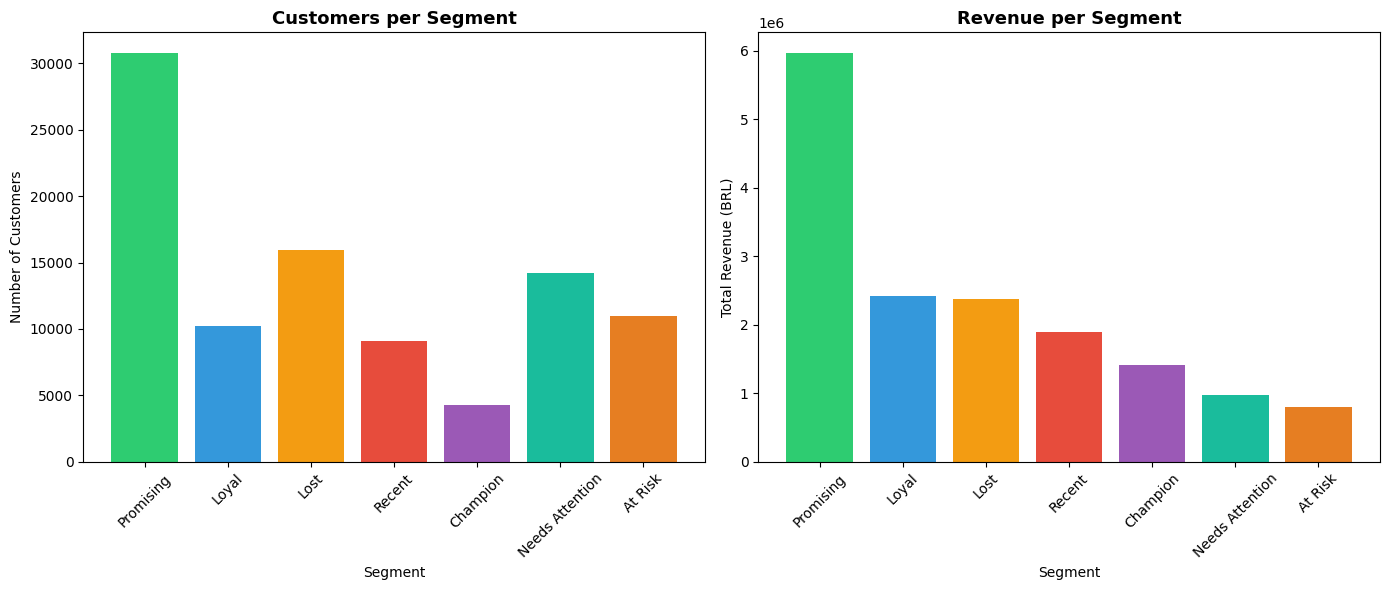

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#9b59b6','#1abc9c','#e67e22']

# Plot 1: Customer count per segment
axes[0].bar(segment_summary['customer_segment'], 
            segment_summary['count'], color=colors)
axes[0].set_title('Customers per Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Revenue per segment
axes[1].bar(segment_summary['customer_segment'],
            segment_summary['total_revenue'], color=colors)
axes[1].set_title('Revenue per Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Revenue (BRL)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../dashboard/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# RFM scatter plot (recency vs monetary)

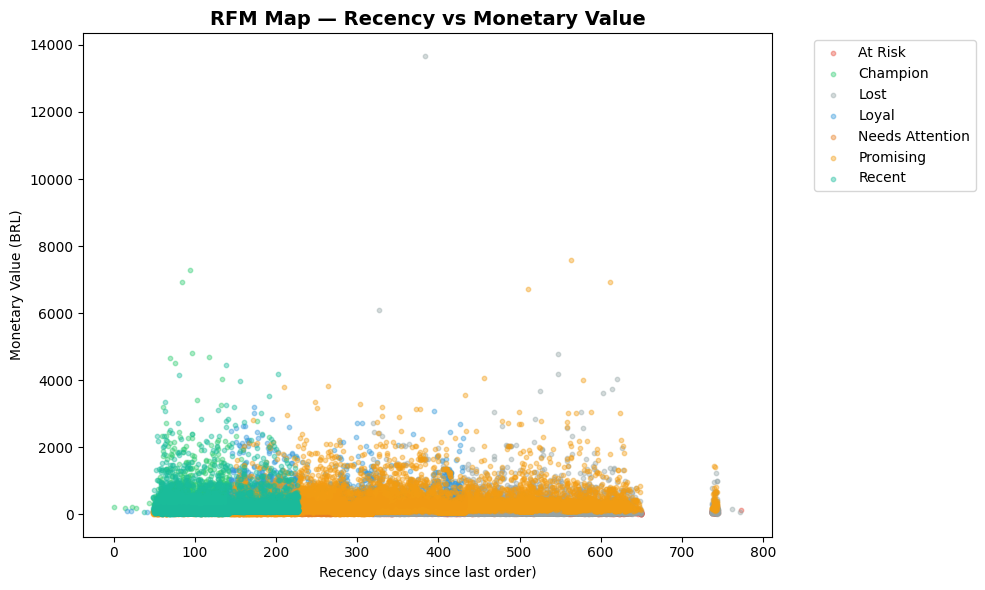

In [6]:
plt.figure(figsize=(10, 6))

segment_colors = {
    'Champion':        '#2ecc71',
    'Loyal':           '#3498db',
    'Recent':          '#1abc9c',
    'Promising':       '#f39c12',
    'Needs Attention': '#e67e22',
    'At Risk':         '#e74c3c',
    'Lost':            '#95a5a6'
}

for segment, group in df_rfm.groupby('customer_segment'):
    plt.scatter(
        group['recency'],
        group['monetary'],
        c=segment_colors.get(segment, '#333'),
        label=segment,
        alpha=0.4,
        s=10
    )

plt.title('RFM Map — Recency vs Monetary Value', fontsize=14, fontweight='bold')
plt.xlabel('Recency (days since last order)')
plt.ylabel('Monetary Value (BRL)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../dashboard/rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

#K-Means clustering using RFM scores

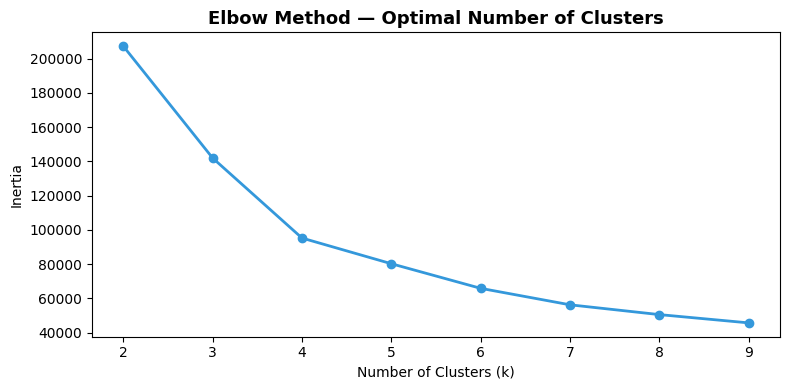

In [7]:
# Scale RFM scores
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_rfm[['recency', 'frequency', 'monetary']])

# Find optimal k using elbow method
inertias = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', linewidth=2, color='#3498db')
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('../dashboard/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply K-Means with optimal k=4

In [8]:
# Use k=4 (optimal for RFM — adjust based on elbow curve)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_rfm['kmeans_cluster'] = kmeans.fit_predict(rfm_scaled)

# Summarize clusters
cluster_summary = (
    df_rfm.groupby('kmeans_cluster')
    .agg(
        count        = ('customer_unique_id', 'count'),
        avg_recency  = ('recency', 'mean'),
        avg_frequency= ('frequency', 'mean'),
        avg_monetary = ('monetary', 'mean')
    )
    .round(2)
    .reset_index()
)

print("K-Means Cluster Summary:")
print(cluster_summary.to_string(index=False))

K-Means Cluster Summary:
 kmeans_cluster  count  avg_recency  avg_frequency  avg_monetary
              0  51890       177.54            1.0        134.66
              1  38339       437.75            1.0        134.34
              2   2845       270.04           2.12        286.05
              3   2465       289.21           1.01       1173.19


# Label cluster

In [9]:
cluster_labels = {
    0: 'Recent One-Timers',
    1: 'Lost Customers',
    2: 'Repeat Buyers',
    3: 'High Value Whales'
}

df_rfm['cluster_label'] = df_rfm['kmeans_cluster'].map(cluster_labels)

# Revenue by cluster
revenue_by_cluster = (
    df_rfm.groupby('cluster_label')
    .agg(
        customers     = ('customer_unique_id', 'count'),
        total_revenue = ('monetary', 'sum'),
        avg_spend     = ('monetary', 'mean')
    )
    .round(2)
    .reset_index()
)

revenue_by_cluster['pct_revenue'] = (
    revenue_by_cluster['total_revenue'] / 
    revenue_by_cluster['total_revenue'].sum() * 100
).round(1)

print(revenue_by_cluster.to_string(index=False))

    cluster_label  customers  total_revenue  avg_spend  pct_revenue
High Value Whales       2465     2891902.96    1173.19         18.3
   Lost Customers      38339     5150401.61     134.34         32.5
Recent One-Timers      51890     6987441.36     134.66         44.1
    Repeat Buyers       2845      813807.31     286.05          5.1


## K-Means Clustering — Key Business Insights

### The Leaky Bucket Problem
94% of Olist customers order exactly once and never return.
Cluster 0 (Recent One-Timers) are actively becoming Cluster 1 (Lost).

### Cluster Strategy

| Cluster | Label | Customers | % Revenue | Action |
|---------|-------|-----------|-----------|--------|
| 3 | High Value Whales | 2,465 | 18% | VIP program immediately |
| 2 | Repeat Buyers | 2,845 | 5% | Loyalty rewards |
| 0 | Recent One-Timers | 51,890 | 44% | Re-engagement campaign |
| 1 | Lost Customers | 38,339 | 33% | Win-back discount |

### Biggest Opportunity
Converting just 5% of Cluster 0 (Recent One-Timers) 
into Repeat Buyers would generate an additional R$390K in revenue.

Write K-Means results back to BigQuery

In [ ]:
from google.cloud import bigquery

# Select cluster data
df_kmeans = df_rfm[['customer_unique_id', 'kmeans_cluster']].copy()
df_kmeans['kmeans_cluster'] = df_kmeans['kmeans_cluster'].astype(int)

# Write to BigQuery
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE"
)

client.load_table_from_dataframe(
    df_kmeans,
    "olist_analytics.ml_kmeans_segments",
    job_config=job_config
).result()

print(f"✅ Written {len(df_kmeans):,} rows to ml_kmeans_segments")

✅ Written 95,539 rows to ml_kmeans_segments
